In [6]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import librosa
import librosa.display
import tensorflow as tf
import torch
import os

print(f"Python Version: {sys.version}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"Librosa Version: {librosa.__version__}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"PyTorch Version: {torch.__version__}")

BASE_DIR = "/kaggle/input/timit-ready/TIMIT_READY"
TRAIN_DIR = os.path.join(BASE_DIR, "TRAIN")
TEST_DIR = os.path.join(BASE_DIR, "TEST")

Python Version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
NumPy Version: 2.0.2
Pandas Version: 2.2.2
Scikit-Learn Version: 1.6.1
Librosa Version: 0.11.0
TensorFlow Version: 2.19.0
PyTorch Version: 2.8.0+cu126



Örnek Kadın Sesi Yolu: /kaggle/input/timit-ready/TIMIT_READY/TRAIN/FEMALE/DR3_FLAC0_SI2161.WAV
Örnek Erkek Sesi Yolu: /kaggle/input/timit-ready/TIMIT_READY/TRAIN/MALE/DR3_MAKR0_SX92.WAV


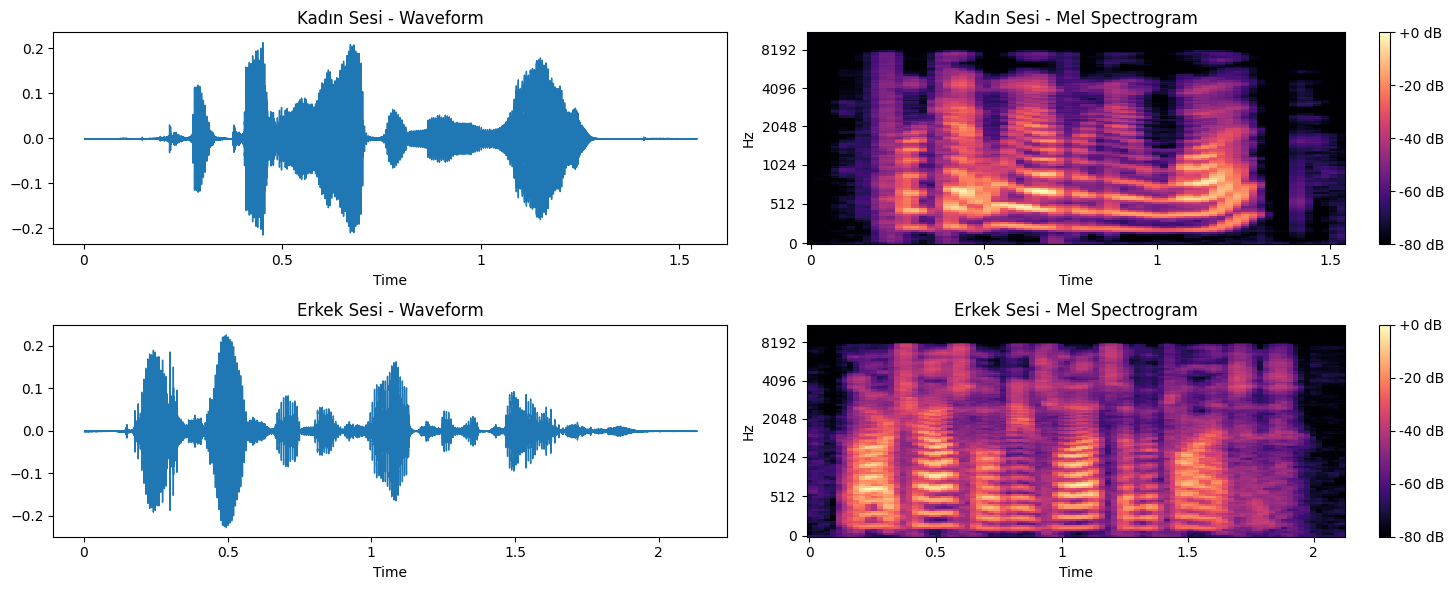

In [ ]:
female_sample_path = os.path.join(TRAIN_DIR, "FEMALE", os.listdir(os.path.join(TRAIN_DIR, "FEMALE"))[0])
male_sample_path = os.path.join(TRAIN_DIR, "MALE", os.listdir(os.path.join(TRAIN_DIR, "MALE"))[0])

print(f"\nÖrnek Kadın Sesi Yolu: {female_sample_path}")
print(f"Örnek Erkek Sesi Yolu: {male_sample_path}")

# 4. Sinyal İşleme Görselleştirmesi (Spectrogram Karşılaştırması)
def plot_comparison(female_path, male_path):
    plt.figure(figsize=(15, 6))

    # --- Kadın Sesi ---
    plt.subplot(2, 2, 1)
    y_f, sr_f = librosa.load(female_path, duration=3) 
    librosa.display.waveshow(y_f, sr=sr_f)
    plt.title("Kadın Sesi - Waveform")
    
    plt.subplot(2, 2, 2)
    # Mel Spectrogram 
    S_f = librosa.feature.melspectrogram(y=y_f, sr=sr_f, n_mels=128)
    S_db_f = librosa.power_to_db(S_f, ref=np.max)
    librosa.display.specshow(S_db_f, sr=sr_f, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title("Kadın Sesi - Mel Spectrogram")

    # --- Erkek Sesi ---
    plt.subplot(2, 2, 3)
    y_m, sr_m = librosa.load(male_path, duration=3)
    librosa.display.waveshow(y_m, sr=sr_m)
    plt.title("Erkek Sesi - Waveform")
    
    plt.subplot(2, 2, 4)
    S_m = librosa.feature.melspectrogram(y=y_m, sr=sr_m, n_mels=128)
    S_db_m = librosa.power_to_db(S_m, ref=np.max)
    librosa.display.specshow(S_db_m, sr=sr_m, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title("Erkek Sesi - Mel Spectrogram")

    plt.tight_layout()
    plt.show()

plot_comparison(female_sample_path, male_sample_path)

İşleniyor: FEMALE (1360 dosya)...


100%|██████████| 1360/1360 [00:27<00:00, 49.76it/s]


İşleniyor: MALE (3260 dosya)...


100%|██████████| 3260/3260 [00:54<00:00, 59.43it/s]



--- Sayısal İstatistikler ---
           count         mean         std          min          25%  \
Cinsiyet                                                              
Erkek     3260.0  2078.806283  260.613611  1369.305920  1902.816905   
Kadın     1360.0  2230.693332  271.052040  1327.192599  2038.300391   

                  50%          75%         max  
Cinsiyet                                        
Erkek     2050.204809  2243.798462  3105.39581  
Kadın     2207.944112  2398.417901  3144.59671  


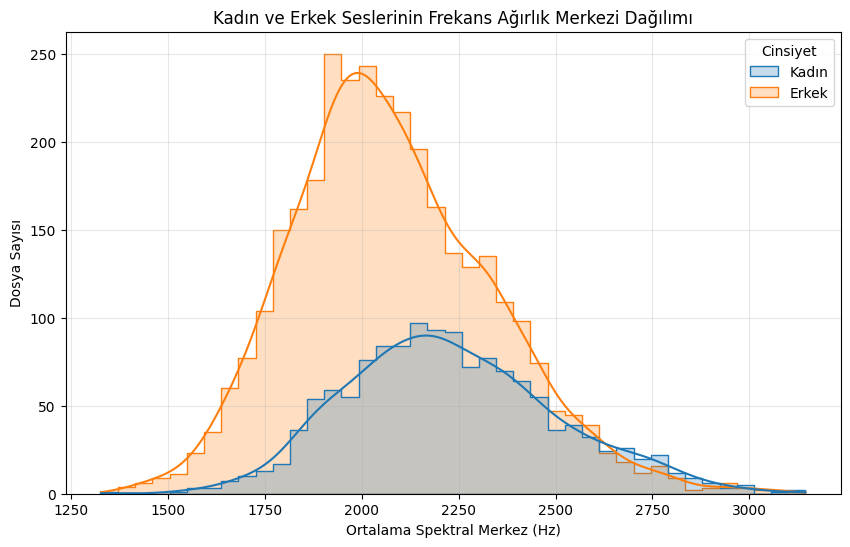

/tmp/ipykernel_55/3097409270.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stats, x="Cinsiyet", y="Spectral_Centroid_Mean", palette="Set2")


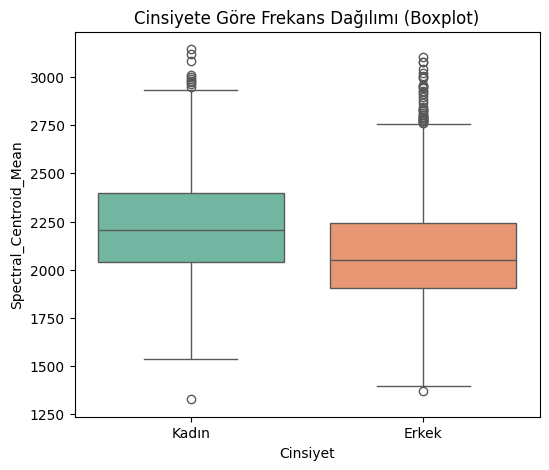

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  

def extract_features_statistics(directory, sample_limit=None):
    data = []
    
    # Kadın ve Erkek klasörlerini gez
    for gender in ["FEMALE", "MALE"]:
        folder_path = os.path.join(directory, gender)
        files = os.listdir(folder_path)
        if sample_limit:
            files = files[:sample_limit]
            
        print(f"İşleniyor: {gender} ({len(files)} dosya)...")
        
        for file in tqdm(files):
            file_path = os.path.join(folder_path, file)
            try:
                y, sr = librosa.load(file_path, duration=3)
                cent = librosa.feature.spectral_centroid(y=y, sr=sr)
                mean_freq = np.mean(cent)
                
                data.append({
                    "Dosya": file,
                    "Cinsiyet": "Kadın" if gender == "FEMALE" else "Erkek",
                    "Spectral_Centroid_Mean": mean_freq
                })
            except Exception as e:
                print(f"Hata: {file} - {str(e)}")
                continue

    return pd.DataFrame(data)


df_stats = extract_features_statistics(TRAIN_DIR, sample_limit=None)

# --- SONUÇLARI GÖRSELLEŞTİR VE YAZDIR ---

print("\n--- Sayısal İstatistikler ---")
summary = df_stats.groupby("Cinsiyet")["Spectral_Centroid_Mean"].describe()
print(summary)

plt.figure(figsize=(10, 6))
sns.histplot(data=df_stats, x="Spectral_Centroid_Mean", hue="Cinsiyet", kde=True, element="step")
plt.title("Kadın ve Erkek Seslerinin Frekans Ağırlık Merkezi Dağılımı")
plt.xlabel("Ortalama Spektral Merkez (Hz)")
plt.ylabel("Dosya Sayısı")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 5))
sns.boxplot(data=df_stats, x="Cinsiyet", y="Spectral_Centroid_Mean", palette="Set2")
plt.title("Cinsiyete Göre Frekans Dağılımı (Boxplot)")
plt.show()

Ses uzunlukları analiz ediliyor...

--- Analiz Sonuçları ---
Toplam Dosya: 4620
Ortalama Süre: 3.07 saniye
Maksimum Süre: 7.79 saniye
95. Persentil (Verinin %95'ini kapsayan süre): 4.70 saniye


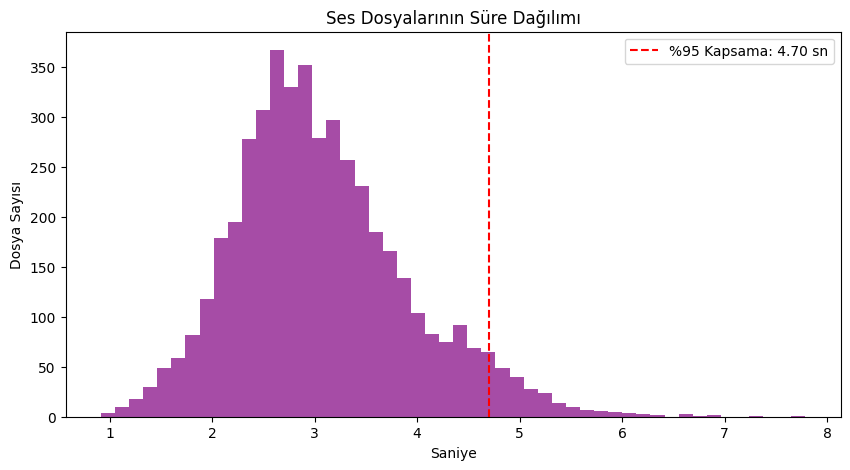


===> ÖNERİLEN MAX_SAMPLES: 75269 (Sample Rate 16000 Hz için) <===


In [ ]:
from tqdm import tqdm

def analyze_lengths(directory):
    durations = []
    
    # Tüm dosyaları gez
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.upper().endswith(".WAV"):
                path = os.path.join(root, file)
                try:
                    duration = librosa.get_duration(path=path)
                    durations.append(duration)
                except:
                    continue
                    
    return np.array(durations)

print("Ses uzunlukları analiz ediliyor...")
durations = analyze_lengths(TRAIN_DIR)

# İstatistikler
perc_95 = np.percentile(durations, 95)
mean_dur = np.mean(durations)
max_dur = np.max(durations)

print(f"\n--- Analiz Sonuçları ---")
print(f"Toplam Dosya: {len(durations)}")
print(f"Ortalama Süre: {mean_dur:.2f} saniye")
print(f"Maksimum Süre: {max_dur:.2f} saniye")
print(f"95. Persentil (Verinin %95'ini kapsayan süre): {perc_95:.2f} saniye")

# Görselleştirme
plt.figure(figsize=(10, 5))
plt.hist(durations, bins=50, color='purple', alpha=0.7)
plt.axvline(perc_95, color='r', linestyle='--', label=f'%95 Kapsama: {perc_95:.2f} sn')
plt.title("Ses Dosyalarının Süre Dağılımı")
plt.xlabel("Saniye")
plt.ylabel("Dosya Sayısı")
plt.legend()
plt.show()

# Örnekleme Hızı (Sample Rate) genelde 16000 Hz'dir.
TARGET_SAMPLE_RATE = 16000
SUGGESTED_MAX_SAMPLES = int(perc_95 * TARGET_SAMPLE_RATE)
print(f"\n===> ÖNERİLEN MAX_SAMPLES: {SUGGESTED_MAX_SAMPLES} (Sample Rate {TARGET_SAMPLE_RATE} Hz için) <===")

In [ ]:
import os
import soundfile as sf
import numpy as np
from tqdm import tqdm

OLD_BASE_DIR = "/kaggle/input/timit-ready/TIMIT_READY"
NEW_BASE_DIR = "/kaggle/working/TIMIT_FIXED"

def convert_nist_to_riff(src_root, dst_root):
    """
    NIST SPHERE formatındaki wav dosyalarını okur,
    Standart RIFF WAV formatında yeni bir klasöre kaydeder.
    """
    print(f"Dönüştürme Başlıyor: {src_root} -> {dst_root}")
    
    files_to_process = []
    for root, dirs, files in os.walk(src_root):
        for file in files:
            if file.lower().endswith('.wav'):
                files_to_process.append(os.path.join(root, file))
    
    print(f"Toplam {len(files_to_process)} dosya dönüştürülecek...")
    
    for src_path in tqdm(files_to_process):
        rel_path = os.path.relpath(src_path, src_root)
        dst_path = os.path.join(dst_root, rel_path)
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)
        
        try:
            # Soundfile kütüphanesi NIST formatını otomatik tanır
            data, samplerate = sf.read(src_path)
            
            # Standart WAV (PCM_16) olarak kaydet
            sf.write(dst_path, data, samplerate, subtype='PCM_16')
        except Exception as e:
            print(f"HATA: {src_path} dönüştürülemedi. {e}")

# İşlemi Başlat
if not os.path.exists(NEW_BASE_DIR):
    convert_nist_to_riff(OLD_BASE_DIR, NEW_BASE_DIR)
    print("\n✅ Dönüştürme tamamlandı! Veriler artık TensorFlow ile uyumlu.")
else:
    print("\nℹ️ Veriler zaten dönüştürülmüş, işlem atlanıyor.")

TRAIN_DIR = os.path.join(NEW_BASE_DIR, "TRAIN")
TEST_DIR = os.path.join(NEW_BASE_DIR, "TEST")

print(f"YENİ EĞİTİM YOLU: {TRAIN_DIR}")
print(f"YENİ TEST YOLU  : {TEST_DIR}")

Dönüştürme Başlıyor: /kaggle/input/timit-ready/TIMIT_READY -> /kaggle/working/TIMIT_FIXED
Toplam 6300 dosya dönüştürülecek...


100%|██████████| 6300/6300 [01:04<00:00, 98.40it/s] 


✅ Dönüştürme tamamlandı! Veriler artık TensorFlow ile uyumlu.
YENİ EĞİTİM YOLU: /kaggle/working/TIMIT_FIXED/TRAIN
YENİ TEST YOLU  : /kaggle/working/TIMIT_FIXED/TEST


Dosya yolları taranıyor...
Veri setleri birleştiriliyor (Original + Noise + Reverb)...

Örnek Dönüşümler Görselleştiriliyor...


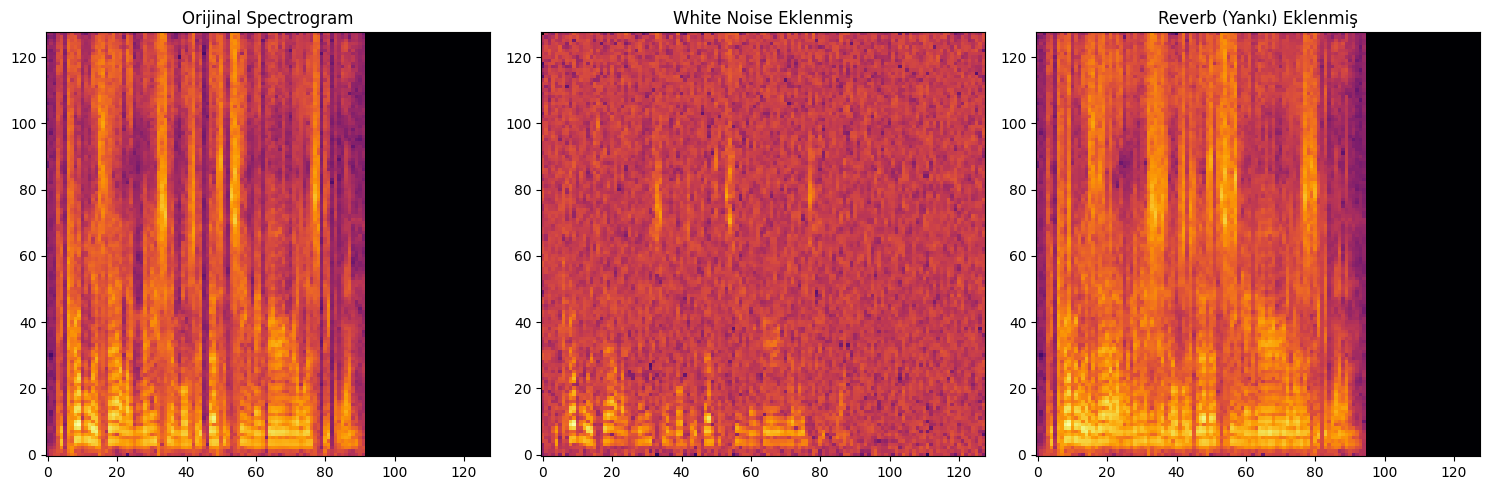


Pipeline üzerinden geçen gerçek veri sayısı hesaplanıyor (Bu işlem birkaç saniye sürebilir)...

DATA AUGMENTATION RAPORU (DOĞRULANMIŞ)
Orijinal Dosya Sayısı          : 4620
Beklenen Toplam Veri Sayısı    : 13860 (Orijinal x 3)
Sayılmış GERÇEK Veri Sayısı    : 13860
----------------------------------------
✅ DURUM: BAŞARILI. Veri kaybı veya fazlalığı yok.


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os


SAMPLE_RATE = 16000
MAX_SAMPLES = 80000 
BATCH_SIZE = 32
IMG_SIZE = (128, 128)

def get_file_paths_and_labels(directory):
    """Klasör yapısından dosya yollarını ve etiketleri çeker."""
    file_paths = []
    labels = []
    # Klasör isimleri alfabetik: FEMALE (0), MALE (1)
    class_names = sorted(os.listdir(directory)) 
    
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(directory, class_name)
        if os.path.isdir(class_dir):
            files = [f for f in os.listdir(class_dir) if f.lower().endswith('.wav')]
            for f in files:
                file_paths.append(os.path.join(class_dir, f))
                labels.append(i) 
            
    return file_paths, labels, class_names

# --- 3. AUGMENTATION FONKSİYONLARI ---

def get_white_noise(audio, noise_factor=0.008):
    """Sese rastgele beyaz gürültü ekler (Statik cızırtı)."""
    noise = tf.random.normal(shape=tf.shape(audio), mean=0.0, stddev=noise_factor, dtype=tf.float32)
    return audio + noise

def get_reverb(audio, decay=0.6, delay_ms=100):
    """
    Delay-and-Sum yöntemiyle Reverb (Yankı) Simülasyonu.
    """
    delay_samples = int(SAMPLE_RATE * (delay_ms / 1000.0))
    padding = tf.zeros([delay_samples], dtype=tf.float32)
    delayed_audio = tf.concat([padding, audio], axis=0)
    delayed_audio = delayed_audio[:tf.shape(audio)[0]] 
    reverbed_audio = audio + (delayed_audio * decay)
    return reverbed_audio

def freq_masking(spectrogram, num_masks=1, mask_max_size=15):
    """Spectrogram augmentation (Görüntü bozulmaları)"""
    spectrogram = tf.image.random_brightness(spectrogram, max_delta=0.2)
    spectrogram = tf.image.random_contrast(spectrogram, lower=0.8, upper=1.2)
    return spectrogram

# --- 4. TEMEL İŞLEME FONKSİYONLARI ---

def load_audio(file_path, label):
    """Dosya okuma ve 5 saniyeye sabitleme."""
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)
    
    audio_len = tf.shape(audio)[0]
    if audio_len >= MAX_SAMPLES:
        max_start = audio_len - MAX_SAMPLES
        start_index = tf.random.uniform([], minval=0, maxval=max_start + 1, dtype=tf.int32)
        audio = audio[start_index : start_index + MAX_SAMPLES]
    else:
        padding = MAX_SAMPLES - audio_len
        audio = tf.pad(audio, [[0, padding]])
    
    return audio, label

def to_spectrogram(audio, label):
    """Audio -> Log-Spectrogram Dönüşümü"""
    spectrogram = tf.signal.stft(audio, frame_length=255, frame_step=128)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.math.log(spectrogram + 1e-6)
    spectrogram = tf.expand_dims(spectrogram, axis=-1)
    spectrogram = tf.image.resize(spectrogram, IMG_SIZE)
    return spectrogram, label

# --- 5. VERİ SETİ OLUŞTURMA VE BİRLEŞTİRME ---

print("Dosya yolları taranıyor...")
train_paths_list, train_labels_list, class_names = get_file_paths_and_labels(TRAIN_DIR)
test_paths_list, test_labels_list, _ = get_file_paths_and_labels(TEST_DIR)

# Tensor Slices oluştur
ds_files = tf.data.Dataset.from_tensor_slices((train_paths_list, train_labels_list))

# A. Orijinal Veri Seti
ds_original = ds_files.map(load_audio, num_parallel_calls=tf.data.AUTOTUNE)

# B. Gürültülü Veri Seti
ds_noise = ds_files.map(load_audio, num_parallel_calls=tf.data.AUTOTUNE)
ds_noise = ds_noise.map(lambda x, y: (get_white_noise(x), y), num_parallel_calls=tf.data.AUTOTUNE)

# C. Yankılı Veri Seti
ds_reverb = ds_files.map(load_audio, num_parallel_calls=tf.data.AUTOTUNE)
ds_reverb = ds_reverb.map(lambda x, y: (get_reverb(x), y), num_parallel_calls=tf.data.AUTOTUNE)

# D. Datasetleri Birleştir 
print("Veri setleri birleştiriliyor (Original + Noise + Reverb)...")
ds_train_full = ds_original.concatenate(ds_noise).concatenate(ds_reverb)

# E. Spectrogram'a Çevir ve Maskele
ds_train_final = ds_train_full.map(to_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)
ds_train_final = ds_train_final.map(lambda x, y: (freq_masking(x), y), num_parallel_calls=tf.data.AUTOTUNE)

# F. Batch ve Shuffle
ds_train_final = ds_train_final.shuffle(buffer_size=2000)
ds_train_final = ds_train_final.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

# --- Test Seti (Sadece Orijinal) ---
ds_test = tf.data.Dataset.from_tensor_slices((test_paths_list, test_labels_list))
ds_test = ds_test.map(load_audio, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.map(to_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

# --- 6. GÖRSEL KONTROL ---
def plot_aug_samples():
    idx = np.random.randint(0, len(train_paths_list))
    path = train_paths_list[idx]
    label = train_labels_list[idx]
    
    audio, _ = load_audio(path, label)
    audio_noise = get_white_noise(audio)
    audio_reverb = get_reverb(audio)
    
    spec_orig, _ = to_spectrogram(audio, label)
    spec_noise, _ = to_spectrogram(audio_noise, label)
    spec_reverb, _ = to_spectrogram(audio_reverb, label)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(spec_orig[:,:,0].numpy().T, origin='lower', aspect='auto', cmap='inferno')
    plt.title("Orijinal Spectrogram")
    
    plt.subplot(1, 3, 2)
    plt.imshow(spec_noise[:,:,0].numpy().T, origin='lower', aspect='auto', cmap='inferno')
    plt.title("White Noise Eklenmiş")
    
    plt.subplot(1, 3, 3)
    plt.imshow(spec_reverb[:,:,0].numpy().T, origin='lower', aspect='auto', cmap='inferno')
    plt.title("Reverb (Yankı) Eklenmiş")
    
    plt.tight_layout()
    plt.show()

print("\nÖrnek Dönüşümler Görselleştiriliyor...")
plot_aug_samples()

# --- 7. İSTATİSTİK VE DOĞRULAMA ---
print("\nPipeline üzerinden geçen gerçek veri sayısı hesaplanıyor (Bu işlem birkaç saniye sürebilir)...")

real_count = 0
for images, labels in ds_train_final:
    real_count += images.shape[0] 

original_count = len(train_paths_list)
expected_count = original_count * 3

print("\n" + "="*40)
print("DATA AUGMENTATION RAPORU (DOĞRULANMIŞ)")
print("="*40)
print(f"Orijinal Dosya Sayısı          : {original_count}")
print(f"Beklenen Toplam Veri Sayısı    : {expected_count} (Orijinal x 3)")
print(f"Sayılmış GERÇEK Veri Sayısı    : {real_count}")
print("-" * 40)

if real_count == expected_count:
    print("✅ DURUM: BAŞARILI. Veri kaybı veya fazlalığı yok.")
else:
    print(f"⚠️ DURUM: Fark var. {expected_count - real_count} adet. (Batch padding kaynaklı olabilir, önemsizdir.)")
print("="*40)


--- YENİ MODEL ÖZETİ (Parametre Sayısına Dikkat) ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,637,761 (6.25 MB)

 Trainable params: 1,635,777 (6.24 MB)

 Non-trainable params: 1,984 (7.75 KB)


🚀 Revize Edilmiş Model Eğitimi Başlıyor...
Epoch 1/25
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.8904 - loss: 0.2775 - val_accuracy: 0.9315 - val_loss: 0.2179 - learning_rate: 0.0010
Epoch 2/25
434/434 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9618 - loss: 0.1564 - val_accuracy: 0.9649 - val_loss: 0.1255 - learning_rate: 0.0010
Epoch 3/25
434/434 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9689 - loss: 0.1084 - val_accuracy: 0.9690 - val_loss: 0.0939 - learning_rate: 0.0010
Epoch 4/25
434/434 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9717 - loss: 0.1017 - val_accuracy: 0.9810 - val_loss: 0.0598 - learning_rate: 0.0010
Epoch 5/25
434/434 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9748 - loss: 0.0857 - val_accuracy: 0.9708 - val_loss: 0.0997 - learning_rate: 0.0010
Epoch 6/25
434/434 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9787 - loss: 0.0660
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
434/434 ━━━━━━━━━━━━━━

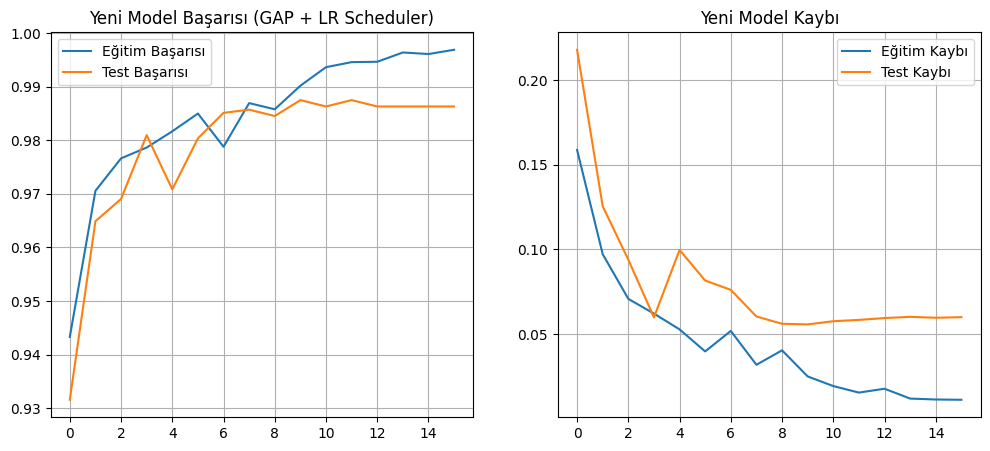


En Yüksek Test Başarısı (v2): 0.9875


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import os

BASE_DIR = "/kaggle/working/TIMIT_FIXED"

# --- 1. MODEL MİMARİSİ  ---
def build_model_refined():
    model = models.Sequential([
        layers.Input(shape=(128, 128, 1)),
        
        # Blok 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Blok 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Blok 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Blok 4 (Daha derin özellikler)
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),

        # Blok 5 (Opsiyonel: İyice derinleştirelim çünkü parametre sayımız azalacak)
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # --- GAP ---
        layers.GlobalAveragePooling2D(),
        
        # Sınıflandırma
        layers.Dense(128, activation='relu'), 
        layers.Dropout(0.5), # Ezber önleyici
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model_v2 = build_model_refined()
print("\n--- YENİ MODEL ÖZETİ (Parametre Sayısına Dikkat) ---")
model_v2.summary()

# --- 2. CALLBACKS (LR Scheduler Eklendi) ---
checkpoint_cb = callbacks.ModelCheckpoint("best_model_v2.keras", save_best_only=True)
early_stopping_cb = callbacks.EarlyStopping(patience=6, restore_best_weights=True)


reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,    
    patience=2,    
    min_lr=1e-6,   
    verbose=1      
)

# --- 3. EĞİTİM ---
class_weight = {0: 1.7, 1: 0.7} 

print("\n🚀 Revize Edilmiş Model Eğitimi Başlıyor...")
history_v2 = model_v2.fit(
    ds_train_final,
    epochs=25,
    validation_data=ds_test,
    class_weight=class_weight, 
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb]
)

# --- 4. SONUÇLARI GÖRSELLEŞTİR ---
acc = history_v2.history['accuracy']
val_acc = history_v2.history['val_accuracy']
loss = history_v2.history['loss']
val_loss = history_v2.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Eğitim Başarısı')
plt.plot(val_acc, label='Test Başarısı')
plt.title('Yeni Model Başarısı (GAP + LR Scheduler)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Eğitim Kaybı')
plt.plot(val_loss, label='Test Kaybı')
plt.title('Yeni Model Kaybı')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nEn Yüksek Test Başarısı (v2): {max(val_acc):.4f}")

Test verisi üzerinde denemeler ve grafik çıktılarını **test-for-safecpeechcasemodel.ipynb**  dosyasında gerçekleştirilmiştir